In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
X,y=make_classification(n_samples=1000,n_features=2,n_classes=2,n_clusters_per_class=1,n_redundant=0)

In [20]:
pd.DataFrame(X)

,0,1
0,-2.010262,-1.388546
1,-0.359495,-0.443137
2,-1.526547,-1.176055
3,-0.992287,0.436461
4,-0.864659,2.463922
...,...,...
995,1.129545,0.684518
996,0.802238,0.600350
997,-1.010760,0.867544
998,-1.330217,-0.681072


In [18]:
pd.DataFrame(y)

,0
0,0
1,0
2,0
3,1
4,1
...,...
995,0
996,0
997,1
998,0


<Axes: xlabel='0', ylabel='1'>

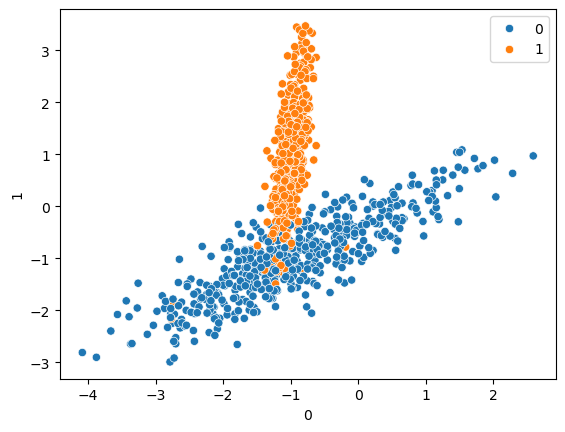

In [4]:
sns.scatterplot(x=pd.DataFrame(X)[0],y=pd.DataFrame(X)[1],hue=y)

In [5]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.35,train_size=0.25,random_state=42,)


In [6]:
from sklearn.svm import SVC
scv= SVC(kernel='linear')

In [7]:
scv.fit(X_train,y_train)

SVC(kernel='linear')

In [8]:
#predict
y_pred = scv.predict(X_test)
from sklearn.metrics import classification_report,confusion_matrix
y_pred=scv.predict(X_test)

In [9]:
print('classification_report(SVC):\n',classification_report(y_pred,y_test))
print('confusion_matrix(SVC):\n',confusion_matrix(y_pred,y_test))

classification_report(SVC):
               precision    recall  f1-score   support

           0       0.95      0.92      0.93       189
           1       0.91      0.94      0.92       161

    accuracy                           0.93       350
   macro avg       0.93      0.93      0.93       350
weighted avg       0.93      0.93      0.93       350

confusion_matrix(SVC):
 [[174  15]
 [ 10 151]]


In [10]:
rb =SVC(kernel='sigmoid')
rb.fit(X_train,y_train)


SVC(kernel='sigmoid')

In [11]:
rbf =SVC(kernel='rbf')
rbf.fit(X_train,y_train)


SVC()

In [12]:
y_pred =rbf.predict(X_test)
print('classification_report(rbf):\n',classification_report(y_pred,y_test))
print('confusion_matrix(rbf):\n',confusion_matrix(y_pred,y_test))


classification_report(rbf):
               precision    recall  f1-score   support

           0       0.97      0.92      0.94       193
           1       0.91      0.96      0.93       157

    accuracy                           0.94       350
   macro avg       0.94      0.94      0.94       350
weighted avg       0.94      0.94      0.94       350

confusion_matrix(rbf):
 [[178  15]
 [  6 151]]


In [13]:
#Hyper paremetes
parem ={
    'C':[0.1,1,10,100,1000],
    'gamma':[1,0.1,0.01,0.001],
    'kernel': ['rbf']
}
from sklearn.model_selection import GridSearchCV
grid=GridSearchCV(estimator=SVC(),param_grid=parem,refit=True,cv=5,verbose=3)

In [14]:
grid.fit(X_train,y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV 1/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.900 total time=   0.0s
[CV 2/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.980 total time=   0.0s
[CV 3/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.960 total time=   0.0s
[CV 4/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.980 total time=   0.0s
[CV 5/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.960 total time=   0.0s
[CV 1/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.840 total time=   0.0s
[CV 2/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.980 total time=   0.0s
[CV 3/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.940 total time=   0.0s
[CV 4/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.960 total time=   0.0s
[CV 5/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.940 total time=   0.0s
[CV 1/5] END .....C=0.1, gamma=0.01, kernel=rbf;, score=0.740 total time=   0.0s
[CV 2/5] END .....C=0.1, gamma=0.01, kernel=rbf

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.1, 1, 10, 100, 1000],
                         'gamma': [1, 0.1, 0.01, 0.001], 'kernel': ['rbf']},
             verbose=3)

In [15]:
y_pred = grid.predict(X_test)
print('classification_report:\n',classification_report(y_pred,y_test))
print('confusion_matrix:\n',confusion_matrix(y_pred,y_test))

classification_report:
               precision    recall  f1-score   support

           0       0.98      0.92      0.95       195
           1       0.91      0.97      0.94       155

    accuracy                           0.95       350
   macro avg       0.94      0.95      0.95       350
weighted avg       0.95      0.95      0.95       350

confusion_matrix:
 [[180  15]
 [  4 151]]


In [16]:
rb.intercept_

array([-2.22383017])

In [17]:
scv.coef_

array([[-1.34672287,  2.3555193 ]])